In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (1025, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows: 723


In [6]:
for column in df.columns:
    print(f"{column}: {df[column].unique()}")
    print("-" * 50)

age: [52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]
--------------------------------------------------
sex: [1 0]
--------------------------------------------------
cp: [0 1 2 3]
--------------------------------------------------
trestbps: [125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]
--------------------------------------------------
chol: [212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 16

In [7]:
print("Target Distribution:")
print(df["target"].value_counts())

print("\nTarget Percentage:")
print(df["target"].value_counts(normalize=True) * 100)

Target Distribution:
target
1    526
0    499
Name: count, dtype: int64

Target Percentage:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


## Data Cleaning

The dataset was examined for missing values, duplicate observations, incorrect data types, and invalid feature values.

No missing values were found. However, 723 exact duplicate rows were identified.

The duplicate observations were removed before model training and evaluation. Retaining identical records could allow the same patient observations to appear in both the training and testing datasets, leading to data leakage and overly optimistic model performance.

After removing duplicates, 302 unique observations remained for further analysis and modeling.

The target variable is approximately balanced between the two classes, so no class-balancing technique was applied initially.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset Shape After Removing Duplicates:", df.shape)
print("Remaining Duplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

print("\nTarget Percentage:")
print(df["target"].value_counts(normalize=True) * 100)

Dataset Shape After Removing Duplicates: (302, 14)
Remaining Duplicate Rows: 0

Target Distribution:
target
1    164
0    138
Name: count, dtype: int64

Target Percentage:
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of the target variable, examine relationships between patient characteristics and heart disease status, identify potential outliers, and investigate correlations among numerical features.

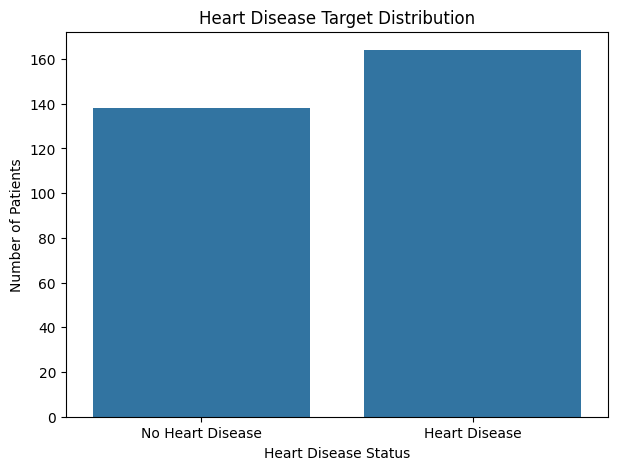

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0, 1],
    labels=["No Heart Disease", "Heart Disease"]
)

plt.show()

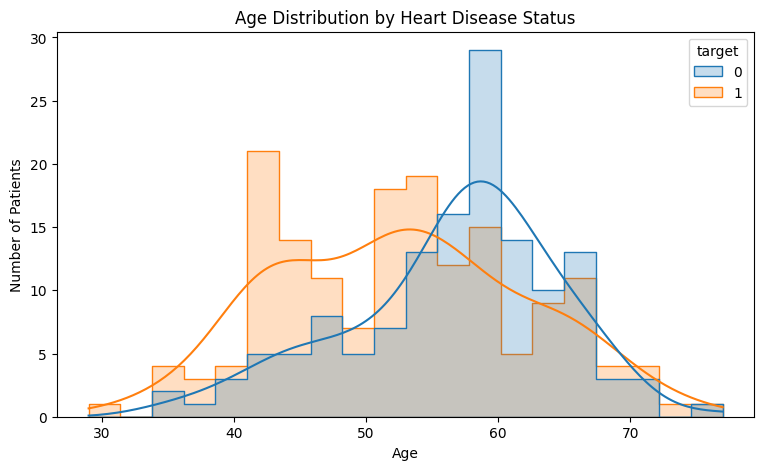

In [10]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    hue="target",
    bins=20,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [11]:
cp_target = pd.crosstab(
    df["cp"],
    df["target"],
    normalize="index"
) * 100

cp_target

target,0,1
cp,,
0,72.727273,27.272727
1,18.000000,82.000000
2,20.930233,79.069767
3,30.434783,69.565217


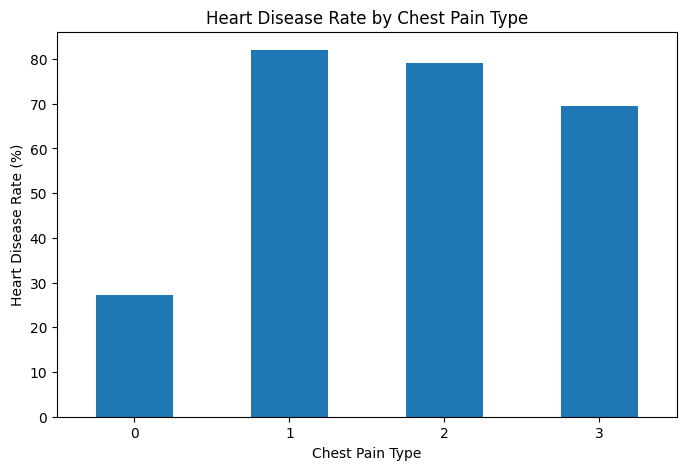

In [12]:
cp_target[1].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Heart Disease Rate by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Heart Disease Rate (%)")
plt.xticks(rotation=0)

plt.show()

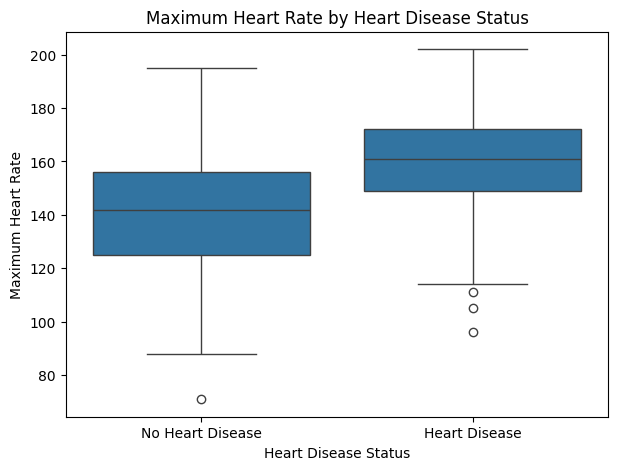

In [13]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="target",
    y="thalach"
)

plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Maximum Heart Rate")

plt.xticks(
    ticks=[0, 1],
    labels=["No Heart Disease", "Heart Disease"]
)

plt.show()

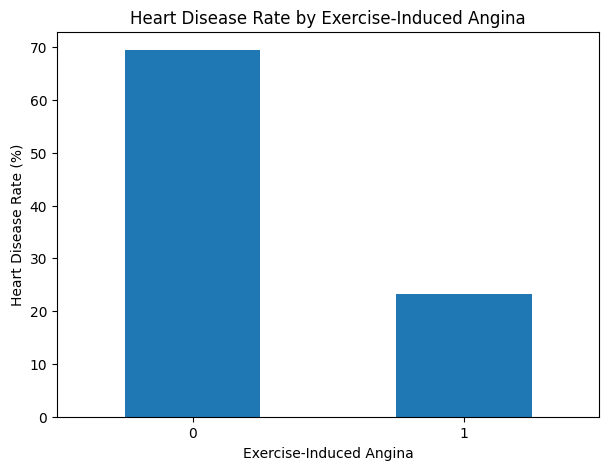

In [14]:
exang_target = pd.crosstab(
    df["exang"],
    df["target"],
    normalize="index"
) * 100

exang_target[1].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Heart Disease Rate by Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Heart Disease Rate (%)")
plt.xticks(rotation=0)

plt.show()

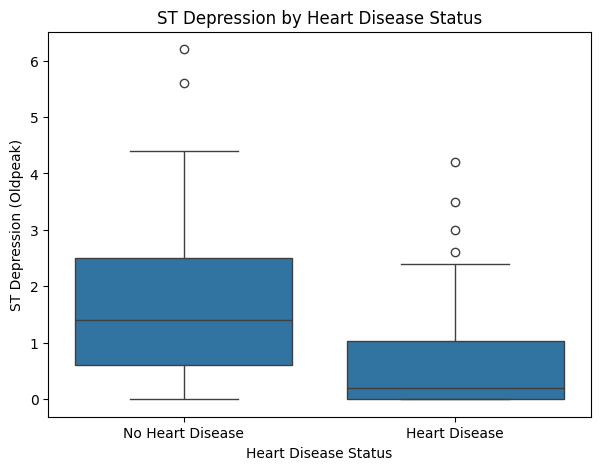

In [15]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="target",
    y="oldpeak"
)

plt.title("ST Depression by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("ST Depression (Oldpeak)")

plt.xticks(
    ticks=[0, 1],
    labels=["No Heart Disease", "Heart Disease"]
)

plt.show()

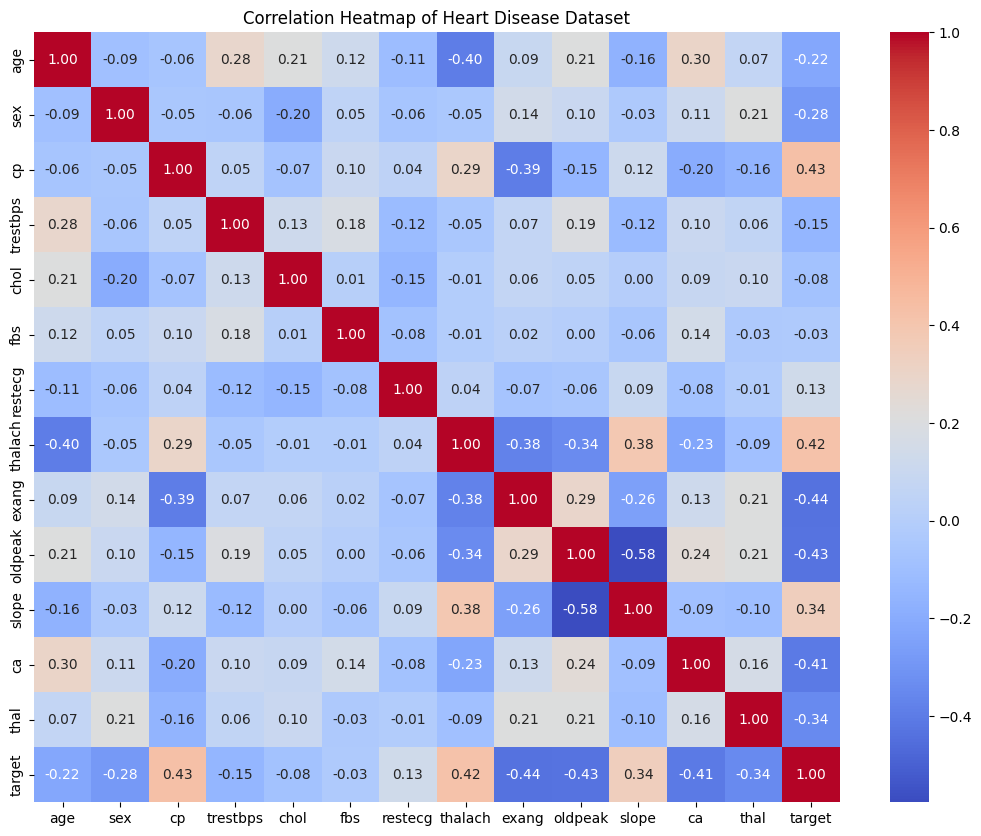

In [16]:
plt.figure(figsize=(13, 10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Heart Disease Dataset")

plt.show()

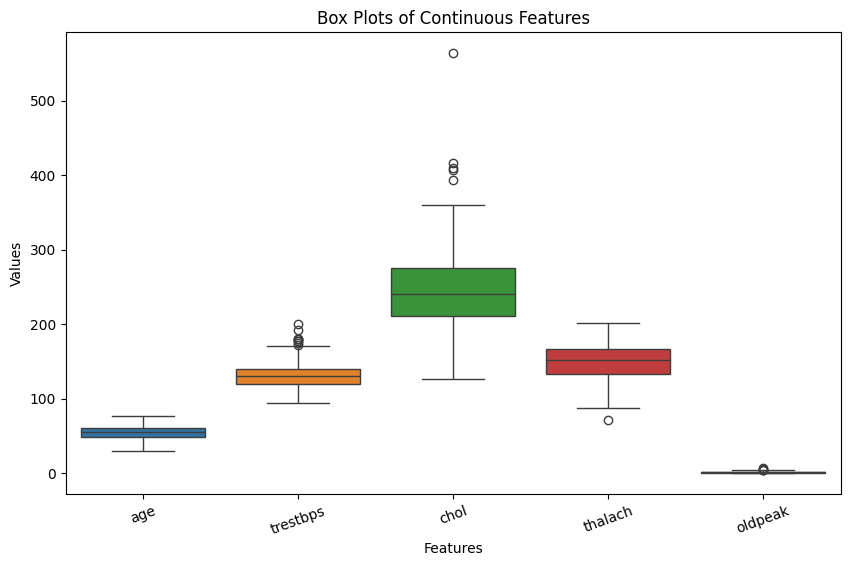

In [17]:
continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[continuous_features]
)

plt.title("Box Plots of Continuous Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=20)

plt.show()

## EDA Observations

- The dataset contained a large number of exact duplicate observations. After removing duplicates, 302 unique patient records remained for analysis and model development.

- The target variable is approximately balanced between patients with and without heart disease, reducing the need for class-balancing techniques during initial model development.

- Chest pain type shows a strong association with the target variable. Patients with chest pain types 1, 2, and 3 have substantially higher heart disease rates than patients with chest pain type 0.

- Patients without exercise-induced angina (`exang = 0`) show a higher heart disease rate in this dataset than patients with exercise-induced angina (`exang = 1`).

- Patients belonging to the positive target class generally have higher maximum heart rates (`thalach`) than patients belonging to the negative target class.

- ST depression (`oldpeak`) tends to be higher among patients in the negative target class, while patients in the positive target class generally have lower oldpeak values.

- The correlation heatmap shows that chest pain type (`cp`) and maximum heart rate (`thalach`) have moderate positive associations with the target variable.

- Exercise-induced angina (`exang`), ST depression (`oldpeak`), number of major vessels (`ca`), and thalassemia (`thal`) show moderate negative associations with the target variable.

- Some continuous variables, particularly resting blood pressure (`trestbps`), cholesterol (`chol`), maximum heart rate (`thalach`), and ST depression (`oldpeak`), contain potential outliers.

- The outliers were retained because they may represent valid clinical measurements, and removing observations without medical justification could result in the loss of meaningful information.

Overall, the exploratory analysis indicates that chest pain type, maximum heart rate, exercise-induced angina, ST depression, number of major vessels, and thalassemia may provide useful predictive information for heart disease classification.

In [18]:
X = df.drop("target", axis=1)
y = df["target"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (302, 13)
Target Shape: (302,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Features: (241, 13)
Testing Features: (61, 13)

Training Target Distribution:
target
1    0.543568
0    0.456432
Name: proportion, dtype: float64

Testing Target Distribution:
target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


In [20]:
continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [21]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            StandardScaler(),
            continuous_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

## Data Preprocessing

The dataset contains both continuous measurements and categorical variables represented using integer codes.

Continuous features, including age, resting blood pressure, cholesterol, maximum heart rate, and ST depression, were standardized using StandardScaler.

Categorical variables were transformed using one-hot encoding. Although these variables are stored numerically, their values represent categories rather than continuous measurements.

The preprocessing transformations were combined with the machine learning models using pipelines. This ensures that transformations are learned only from training data and applied consistently to testing data and future observations, reducing the risk of data leakage.

## Model 1: Logistic Regression

Logistic Regression is used as the baseline classification model for predicting heart disease status.

The model is trained using a pipeline that combines feature preprocessing with classification. Logistic Regression provides a useful baseline because it is computationally efficient, interpretable, and suitable for binary classification problems.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [24]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
--------------------------------
Accuracy  : 0.8525
Precision : 0.8750
Recall    : 0.8485
F1 Score  : 0.8615
ROC-AUC   : 0.9026

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        28
           1       0.88      0.85      0.86        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



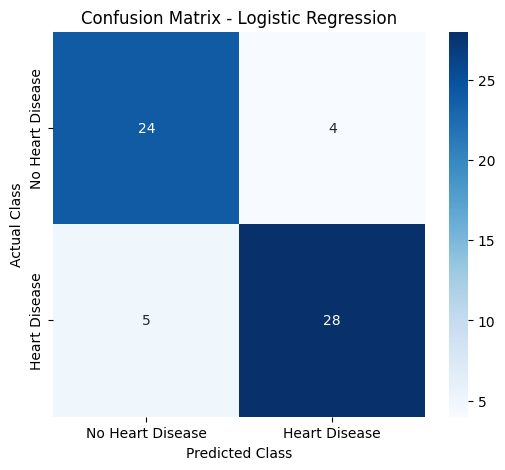

In [26]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

### Logistic Regression Results

The Logistic Regression model achieved an accuracy of approximately 85.3% and a ROC-AUC score of 0.903, indicating strong classification and ranking performance on the test dataset.

For the positive heart disease class, the model achieved a precision of 87.5%, recall of 84.8%, and an F1-score of 86.2%.

The confusion matrix shows that the model correctly classified 24 patients without heart disease and 28 patients with heart disease.

The model incorrectly classified 4 patients without heart disease as positive cases and missed 5 patients who belonged to the positive heart disease class.

Since false-negative predictions represent positive cases that the model fails to identify, recall is an important evaluation metric in addition to accuracy, F1-score, and ROC-AUC.

Overall, Logistic Regression provides a strong baseline model for heart disease classification. However, additional machine learning models should be evaluated and cross-validation should be performed before selecting the final model.

In [28]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [29]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1 Score  : {f1_dt:.4f}")
print(f"ROC-AUC   : {roc_auc_dt:.4f}")

Decision Tree Performance
--------------------------------
Accuracy  : 0.6557
Precision : 0.6765
Recall    : 0.6970
F1 Score  : 0.6866
ROC-AUC   : 0.6521


In [30]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [31]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

Random Forest Performance
--------------------------------
Accuracy  : 0.8197
Precision : 0.8438
Recall    : 0.8182
F1 Score  : 0.8308
ROC-AUC   : 0.8896


In [32]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],

    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf
    ]
})

model_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.852459,0.875000,0.848485,0.861538,0.902597
1,Random Forest,0.819672,0.843750,0.818182,0.830769,0.889610
2,Decision Tree,0.655738,0.676471,0.696970,0.686567,0.652056


### Model Comparison

Three classification algorithms were evaluated for heart disease prediction: Logistic Regression, Decision Tree Classifier, and Random Forest Classifier.

Logistic Regression achieved the best overall test-set performance with an accuracy of approximately 85.3%, precision of 87.5%, recall of 84.8%, F1-score of 86.2%, and ROC-AUC score of 0.903.

Random Forest achieved an accuracy of approximately 82.0% and a ROC-AUC score of 0.890. Although its predictive performance was relatively strong, it did not outperform Logistic Regression on any of the evaluated test-set metrics.

Decision Tree achieved the weakest performance, with an accuracy of approximately 65.6% and a ROC-AUC score of approximately 0.652.

Based on the current test-set results, Logistic Regression provides the strongest overall predictive performance. However, because only 302 unique observations are available, training-testing performance and stratified cross-validation should be examined before selecting the final model.

In [33]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

for name, model in models.items():

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_prob)
    test_auc = roc_auc_score(y_test, test_prob)

    print(name)
    print(f"Training ROC-AUC : {train_auc:.4f}")
    print(f"Testing ROC-AUC  : {test_auc:.4f}")
    print("-" * 40)

Logistic Regression
Training ROC-AUC : 0.9480
Testing ROC-AUC  : 0.9026
----------------------------------------
Decision Tree
Training ROC-AUC : 1.0000
Testing ROC-AUC  : 0.6521
----------------------------------------
Random Forest
Training ROC-AUC : 1.0000
Testing ROC-AUC  : 0.8896
----------------------------------------


In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = {}

for name, model in models.items():

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results[name] = cv_scores

    print(name)
    print("Cross-Validation ROC-AUC Scores:", np.round(cv_scores, 4))
    print(f"Mean CV ROC-AUC : {cv_scores.mean():.4f}")
    print(f"Std CV ROC-AUC  : {cv_scores.std():.4f}")
    print("-" * 55)

Logistic Regression
Cross-Validation ROC-AUC Scores: [0.9123 0.9481 0.8884 0.9057 0.9338]
Mean CV ROC-AUC : 0.9177
Std CV ROC-AUC  : 0.0210
-------------------------------------------------------
Decision Tree
Cross-Validation ROC-AUC Scores: [0.6353 0.7938 0.6853 0.7037 0.6936]
Mean CV ROC-AUC : 0.7023
Std CV ROC-AUC  : 0.0515
-------------------------------------------------------
Random Forest
Cross-Validation ROC-AUC Scores: [0.8707 0.9167 0.8767 0.9007 0.8934]
Mean CV ROC-AUC : 0.8916
Std CV ROC-AUC  : 0.0166
-------------------------------------------------------


In [35]:
for name, model in models.items():

    f1_cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="f1",
        n_jobs=-1
    )

    print(name)
    print("Cross-Validation F1 Scores:", np.round(f1_cv_scores, 4))
    print(f"Mean CV F1 : {f1_cv_scores.mean():.4f}")
    print(f"Std CV F1  : {f1_cv_scores.std():.4f}")
    print("-" * 55)

Logistic Regression
Cross-Validation F1 Scores: [0.8136 0.9014 0.8182 0.8986 0.8571]
Mean CV F1 : 0.8578
Std CV F1  : 0.0377
-------------------------------------------------------
Decision Tree
Cross-Validation F1 Scores: [0.5818 0.8333 0.6885 0.7097 0.7353]
Mean CV F1 : 0.7097
Std CV F1  : 0.0809
-------------------------------------------------------
Random Forest
Cross-Validation F1 Scores: [0.7143 0.8333 0.8    0.8485 0.7812]
Mean CV F1 : 0.7955
Std CV F1  : 0.0470
-------------------------------------------------------


### Overfitting and Cross-Validation Analysis

The training and testing ROC-AUC scores were compared to evaluate the generalization performance of the classification models.

Logistic Regression achieved a training ROC-AUC score of 0.948 and a testing ROC-AUC score of 0.903. Although the training performance was higher, the model maintained strong performance on unseen test data.

Decision Tree achieved a perfect training ROC-AUC score of 1.000 but a testing ROC-AUC score of only 0.652. This large performance difference indicates severe overfitting.

Random Forest also achieved a perfect training ROC-AUC score of 1.000, while its testing ROC-AUC score decreased to 0.890, indicating overfitting.

Stratified five-fold cross-validation using the F1-score further demonstrated that Logistic Regression provides the strongest and most stable classification performance.

Logistic Regression achieved the highest mean cross-validation F1-score of approximately 0.858 with a standard deviation of 0.038.

Random Forest achieved a mean cross-validation F1-score of approximately 0.796, while Decision Tree achieved a mean cross-validation F1-score of approximately 0.710.

Based on the training-testing performance and cross-validation F1-score results, Logistic Regression currently provides the best overall generalization performance.

## Logistic Regression Hyperparameter Tuning

The Logistic Regression model achieved the strongest test-set and cross-validation performance among the evaluated classification algorithms.

To determine whether its generalization performance could be improved further, the inverse regularization strength parameter (`C`) was tuned using GridSearchCV.

Smaller values of `C` apply stronger regularization, while larger values apply weaker regularization.

Stratified five-fold cross-validation and ROC-AUC were used for hyperparameter selection.

In [36]:
from sklearn.model_selection import GridSearchCV

tuned_logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

param_grid = {
    "classifier__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

logistic_grid = GridSearchCV(
    estimator=tuned_logistic_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=skf,
    n_jobs=-1,
    return_train_score=True
)

logistic_grid.fit(X_train, y_train)

best_logistic_model = logistic_grid.best_estimator_

print("Best C:", logistic_grid.best_params_["classifier__C"])
print("Best Training CV ROC-AUC:", logistic_grid.best_score_)

Best C: 10
Best Training CV ROC-AUC: 0.9271173271173272


In [37]:
y_pred_tuned = best_logistic_model.predict(X_test)

y_prob_tuned = best_logistic_model.predict_proba(X_test)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("Tuned Logistic Regression Performance")
print("-------------------------------------")
print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1 Score  : {f1_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_tuned:.4f}")

Tuned Logistic Regression Performance
-------------------------------------
Accuracy  : 0.8361
Precision : 0.8485
Recall    : 0.8485
F1 Score  : 0.8485
ROC-AUC   : 0.9026


In [38]:
logistic_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_tuned
    ],

    "Precision": [
        precision_lr,
        precision_tuned
    ],

    "Recall": [
        recall_lr,
        recall_tuned
    ],

    "F1 Score": [
        f1_lr,
        f1_tuned
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_tuned
    ]
})

logistic_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.852459,0.875000,0.848485,0.861538,0.902597
1,Tuned Logistic Regression,0.836066,0.848485,0.848485,0.848485,0.902597


In [39]:
tuned_cv_auc = cross_val_score(
    best_logistic_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

tuned_cv_f1 = cross_val_score(
    best_logistic_model,
    X,
    y,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

print("Tuned Logistic Regression")

print("\nFull-Dataset CV ROC-AUC Scores:",
      np.round(tuned_cv_auc, 4))

print(f"Mean CV ROC-AUC : {tuned_cv_auc.mean():.4f}")
print(f"Std CV ROC-AUC  : {tuned_cv_auc.std():.4f}")

print("\nFull-Dataset CV F1 Scores:",
      np.round(tuned_cv_f1, 4))

print(f"Mean CV F1 : {tuned_cv_f1.mean():.4f}")
print(f"Std CV F1  : {tuned_cv_f1.std():.4f}")

Tuned Logistic Regression

Full-Dataset CV ROC-AUC Scores: [0.9156 0.9481 0.8917 0.8945 0.9248]
Mean CV ROC-AUC : 0.9149
Std CV ROC-AUC  : 0.0207

Full-Dataset CV F1 Scores: [0.8333 0.8889 0.8125 0.8824 0.8406]
Mean CV F1 : 0.8515
Std CV F1  : 0.0294


### Hyperparameter Tuning Results

GridSearchCV selected a regularization parameter value of `C = 10` as the best configuration based on cross-validation performed on the training dataset.

The Tuned Logistic Regression model achieved an accuracy of approximately 83.6%, precision of 84.8%, recall of 84.8%, F1-score of 84.8%, and ROC-AUC score of 0.903 on the test dataset.

The baseline and tuned Logistic Regression models achieved identical test ROC-AUC scores. However, the baseline model achieved higher accuracy, precision, and F1-score.

Full-dataset stratified cross-validation also showed that the baseline Logistic Regression model achieved slightly higher mean ROC-AUC and mean F1-score than the tuned model.

Therefore, hyperparameter tuning did not provide a meaningful improvement in predictive performance, and the baseline Logistic Regression model was retained as the final model.

In [40]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Logistic Regression",
        "Random Forest",
        "Decision Tree"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_tuned,
        accuracy_rf,
        accuracy_dt
    ],

    "Precision": [
        precision_lr,
        precision_tuned,
        precision_rf,
        precision_dt
    ],

    "Recall": [
        recall_lr,
        recall_tuned,
        recall_rf,
        recall_dt
    ],

    "F1 Score": [
        f1_lr,
        f1_tuned,
        f1_rf,
        f1_dt
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_tuned,
        roc_auc_rf,
        roc_auc_dt
    ],

    "Mean CV ROC-AUC": [
        0.9177,
        tuned_cv_auc.mean(),
        0.8916,
        0.7023
    ],

    "Mean CV F1": [
        0.8578,
        tuned_cv_f1.mean(),
        0.7955,
        0.7097
    ]
})

final_results.sort_values(
    by="Mean CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Mean CV ROC-AUC,Mean CV F1
0,Logistic Regression,0.852459,0.875000,0.848485,0.861538,0.902597,0.917700,0.857800
1,Tuned Logistic Regression,0.836066,0.848485,0.848485,0.848485,0.902597,0.914936,0.851531
2,Random Forest,0.819672,0.843750,0.818182,0.830769,0.889610,0.891600,0.795500
3,Decision Tree,0.655738,0.676471,0.696970,0.686567,0.652056,0.702300,0.709700


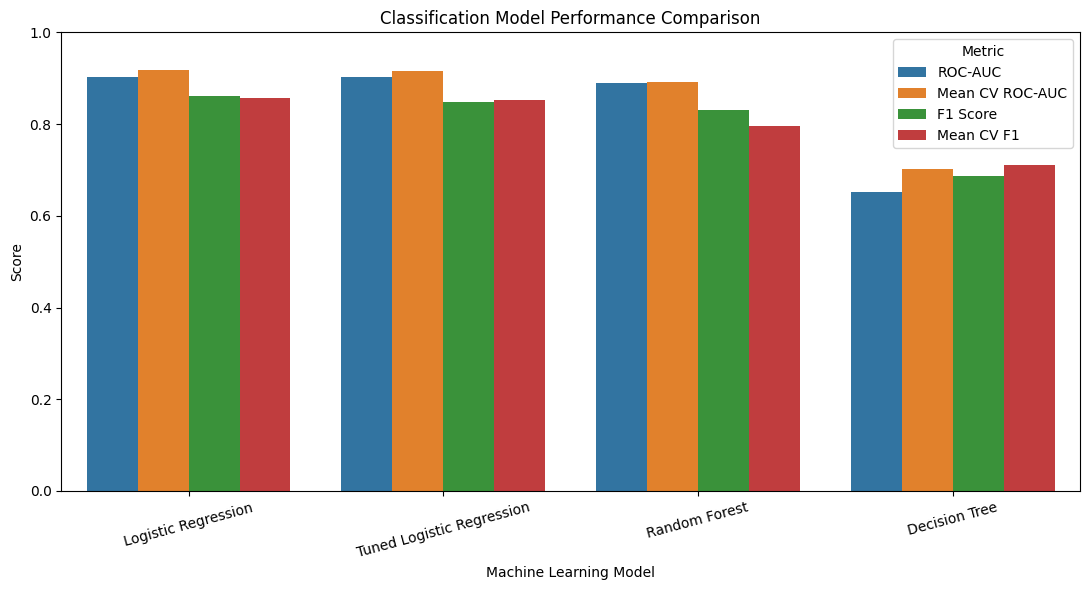

In [41]:
comparison_plot = final_results.melt(
    id_vars="Model",
    value_vars=[
        "ROC-AUC",
        "Mean CV ROC-AUC",
        "F1 Score",
        "Mean CV F1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.legend(title="Metric")

plt.tight_layout()
plt.show()

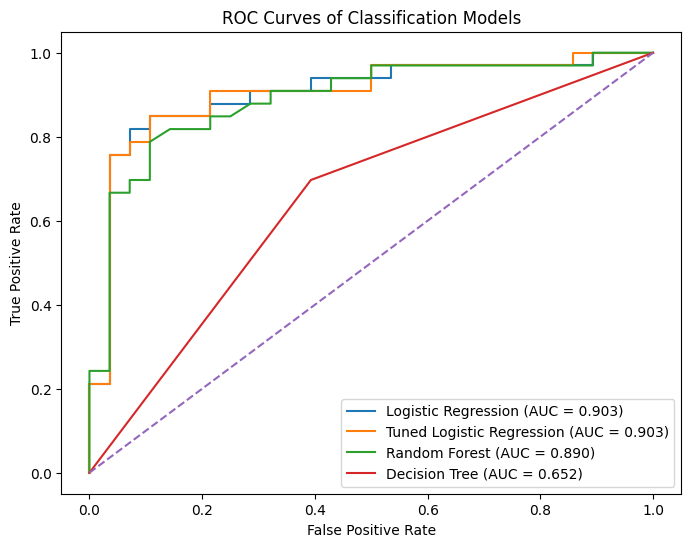

In [42]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_tuned, tpr_tuned, _ = roc_curve(
    y_test,
    y_prob_tuned
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_prob_dt
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label=f"Tuned Logistic Regression (AUC = {roc_auc_tuned:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_dt:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curves of Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [43]:
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

print("Features Associated with Higher Predicted Heart Disease Probability:")
display(coefficient_df.head(10))

print("Features Associated with Lower Predicted Heart Disease Probability:")
display(
    coefficient_df.tail(10)
    .sort_values("Coefficient")
)

Features Associated with Higher Predicted Heart Disease Probability:


,Feature,Coefficient
7,categorical__cp_2,1.477665
8,categorical__cp_3,1.434870
3,continuous__thalach,0.777291
6,categorical__cp_1,0.605963
20,categorical__thal_2,0.510780
19,categorical__thal_1,0.491441
18,categorical__ca_4,0.383769
10,categorical__restecg_1,0.362421
14,categorical__slope_2,0.328840
0,continuous__age,0.216128


Features Associated with Lower Predicted Heart Disease Probability:


,Feature,Coefficient
16,categorical__ca_2,-2.051868
15,categorical__ca_1,-1.487643
5,categorical__sex_1,-1.334733
17,categorical__ca_3,-1.014090
12,categorical__exang_1,-0.848428
21,categorical__thal_3,-0.739261
13,categorical__slope_1,-0.428363
4,continuous__oldpeak,-0.341537
1,continuous__trestbps,-0.281987
2,continuous__chol,-0.223189


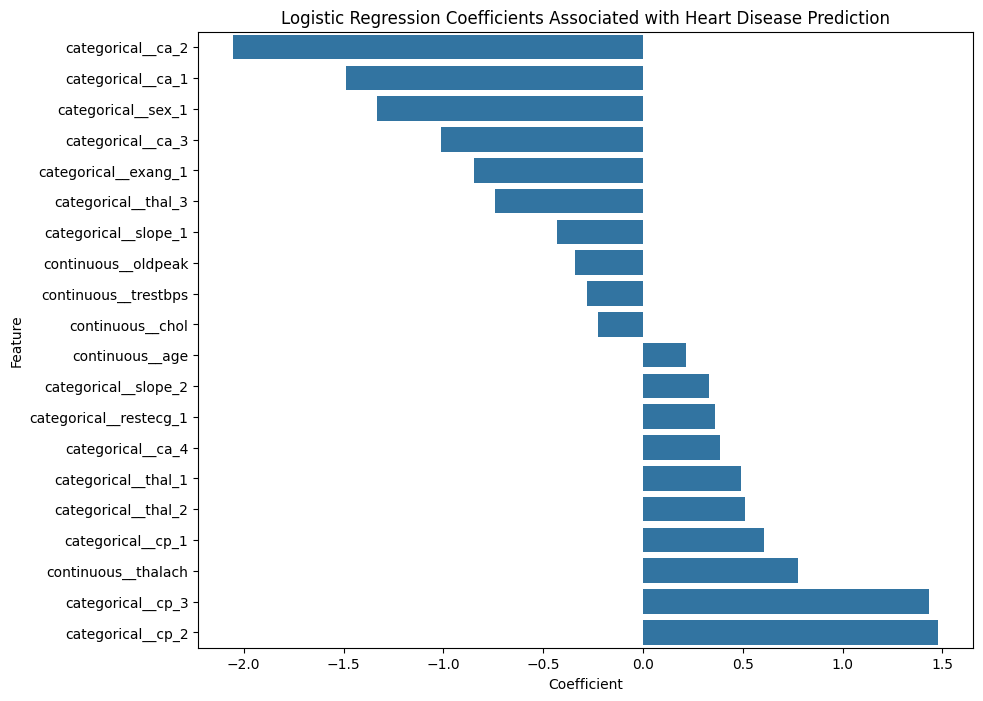

In [44]:
top_positive = coefficient_df.head(10)

top_negative = coefficient_df.tail(10)

important_coefficients = pd.concat([
    top_negative,
    top_positive
]).drop_duplicates().sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=important_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Coefficients Associated with Heart Disease Prediction")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

### Coefficient Interpretation

The coefficients of the final Logistic Regression model were examined to understand which patient characteristics were associated with higher or lower predicted probability of belonging to the positive heart disease class.

Positive coefficients indicate an association with higher predicted log-odds of the positive target class, while negative coefficients indicate an association with lower predicted log-odds, assuming other model features remain constant.

Continuous variables were standardized before model training. Therefore, their coefficients represent the change in predicted log-odds associated with a one-standard-deviation increase in the corresponding feature.

Categorical variables were one-hot encoded, and their coefficients represent differences relative to the reference category removed during encoding.

The coefficient analysis describes associations learned by the model and should not be interpreted as evidence that individual patient characteristics directly cause heart disease.

## Final Model Selection

Logistic Regression was selected as the final model for heart disease prediction.

The baseline Logistic Regression model achieved an accuracy of approximately 85.3%, precision of 87.5%, recall of 84.8%, F1-score of 86.2%, and ROC-AUC score of approximately 0.903 on the held-out test dataset.

Stratified five-fold cross-validation further demonstrated strong and relatively stable generalization performance. Logistic Regression achieved a mean cross-validation ROC-AUC score of approximately 0.918 and a mean cross-validation F1-score of approximately 0.858.

Random Forest achieved strong predictive performance but exhibited overfitting, with a training ROC-AUC score of 1.000 and lower testing and cross-validation performance.

Decision Tree showed severe overfitting and substantially weaker test-set and cross-validation performance.

Hyperparameter tuning selected a regularization parameter value of C = 10. However, the tuned Logistic Regression model did not improve test-set performance or full-dataset cross-validation performance compared with the baseline model.

Therefore, the baseline Logistic Regression model was selected because it provided the best balance of predictive performance, generalization, stability, and interpretability among the evaluated models.

## Conclusion

This project developed a machine learning classification workflow for predicting heart disease status using patient demographic and clinical characteristics.

The original dataset contained 1,025 observations, including 723 exact duplicate records. Duplicate observations were removed before model development to reduce the risk of data leakage and overly optimistic model evaluation, leaving 302 unique observations.

Exploratory Data Analysis identified meaningful associations between the target variable and several patient characteristics, including chest pain type, maximum heart rate, exercise-induced angina, ST depression, number of major vessels, and thalassemia category.

Continuous variables were standardized, while categorical variables represented using integer codes were transformed using one-hot encoding. These preprocessing steps were combined with the machine learning models using pipelines to reduce data leakage and ensure consistent transformation of training and testing data.

Logistic Regression, Decision Tree, and Random Forest classifiers were evaluated using accuracy, precision, recall, F1-score, ROC-AUC, training-testing performance comparison, and stratified five-fold cross-validation.

Logistic Regression achieved the strongest overall generalization performance, with a test ROC-AUC score of approximately 0.903, mean cross-validation ROC-AUC of approximately 0.918, and mean cross-validation F1-score of approximately 0.858.

Decision Tree and Random Forest exhibited overfitting, while Logistic Regression demonstrated stronger stability across unseen subsets of the dataset.

Hyperparameter tuning of Logistic Regression did not improve predictive performance, demonstrating that additional model complexity or tuning does not necessarily lead to better generalization.

Overall, Logistic Regression provided the best balance between predictive performance, generalization, stability, and interpretability for this dataset.

Future improvements could include evaluation on larger independent clinical datasets, nested cross-validation for model selection and unbiased performance estimation, probability calibration, additional regularized linear models, gradient boosting algorithms, and model interpretation techniques such as SHAP.

The developed model is intended as an educational machine learning project and should not be used as a clinical diagnostic system.